In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df

,임신횟수,혈당,혈압,피부두께,인슐린,BMI,가족력지표,나이,당뇨
0,6,148.0,72.0,35.0,159.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,95.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,159.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
712,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
713,2,122.0,70.0,27.0,95.0,36.8,0.340,27,0
714,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
715,1,126.0,60.0,32.0,159.0,30.1,0.349,47,1


In [3]:
# 모든 지표를 사용
df = df[['BMI','혈당','나이','임신횟수','혈압','가족력지표','피부두께','인슐린','당뇨']]

In [14]:
# train과 test로 분리

data = df.iloc[:,:-1]
target = df.iloc[:,-1]

train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    test_size= 0.2,
    stratify=target
)

# 가족력지표와 인슐린의 규모가 다르므로 정규화 진행

ss = StandardScaler()
train_scaled = ss.fit_transform(train_data)
test_scaled = ss.transform(test_data)


In [15]:
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(573, 8)
(144, 8)
(573,)
(144,)


In [6]:
x_train_data, x_valid_data, y_train_target, y_valid_target = train_test_split(
    train_scaled,
    train_target,
    random_state=42,
    test_size= 0.2,
    stratify=train_target
)

In [7]:
train_scaled

array([[ 1.68238713,  1.09820526,  0.27837348, ...,  0.13210762,
         0.4298286 ,  1.73431738],
       [ 1.00819685,  0.23701515,  1.40533219, ..., -0.39039838,
         0.91204454, -0.2580937 ],
       [-1.10630903, -0.41748933, -0.93527437, ..., -1.04431308,
        -1.01681921, -0.51202844],
       ...,
       [-0.23292616,  1.58047172,  1.40533219, ..., -0.53745097,
         0.4298286 ,  0.73811184],
       [ 0.91626182,  0.92596723, -0.41513958, ..., -0.43733006,
         0.4298286 ,  0.73811184],
       [ 1.51383956,  1.09820526,  0.45175174, ...,  0.83921155,
         1.39426048,  2.92585734]], shape=(573, 8))

In [8]:
print(x_train_data.shape)
print(x_valid_data.shape)
print(y_train_target.shape)
print(y_valid_target.shape)

(458, 8)
(115, 8)
(458,)
(115,)


-----
-----
----- 
### SVM

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [16]:
# GridSearchCV 함수
def svc_param_selection(x_train_data, y_train_target, nfolds):
    svc_parameters = [
        {
            'kernel' : ['rbf'], 
            'gamma' : [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10],
            'C' : [0.01, 0.1, 1, 10, 100, 1000] 
        }
    ]
    clf = GridSearchCV(
        SVC(), 
        svc_parameters, 
        cv=nfolds, 
        scoring='accuracy',
        n_jobs=1)
    clf.fit(x_train_data, y_train_target)

    print('최적의 파라미터 :', clf.best_params_)
    print('최고 CV 점수 :',clf.best_score_)
    return clf

# 실행
clf = svc_param_selection(train_scaled, train_target, 5)

# 최종 평가
best_svc = clf.best_estimator_

print("-" * 30)
print("최종 Train 점수 :", best_svc.score(train_scaled, train_target))
print("최종 Test 점수 :", best_svc.score(test_scaled, test_target))

최적의 파라미터 : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
최고 CV 점수 : 0.8673989321128909
------------------------------
최종 Train 점수 : 0.8970331588132635
최종 Test 점수 : 0.8888888888888888


> SVM(RBF) 모델에 대해 GridSearchCV(5-fold)로 하이퍼파라미터를 탐색한 결과, C=100, gamma=0.01이 최적이었다. 교차검증 평균 정확도는 약 0.867이었고, 최종 테스트 정확도는 0.889로 나타났다. 학습 정확도(0.897)와 테스트 정확도(0.889)의 차이가 작아 과적합이 크지 않고 일반화 성능이 양호한 모델로 판단된다.

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

pred = best_svc.predict(test_scaled)

print(confusion_matrix(test_target, pred))
print(classification_report(test_target, pred))

[[85 11]
 [ 5 43]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        96
           1       0.80      0.90      0.84        48

    accuracy                           0.89       144
   macro avg       0.87      0.89      0.88       144
weighted avg       0.90      0.89      0.89       144



> 0 : 일반 1 : 당뇨 
precision(당뇨) : 당뇨라고 예측한 사람 중 80%만 실제 당뇨. -> 정상인데 당뇨로 예측한 사람이 조금 있음 (11명)
recall(당뇨) : 실제 당뇨 환자 중 90%를 찾아냄 48명 중 43명 탐지. 놓친 사람 5명.
accuracy : 89%

>SVM(RBF) 모델은 테스트셋에서 정확도 0.889를 기록했다. 혼동행렬 기준으로 실제 당뇨 환자 48명 중 43명을 올바르게 탐지하여 재현율(Recall) 0.90을 보였다. 이는 당뇨 환자 누락(FN=5)을 비교적 잘 억제한 결과로 해석할 수 있다. 반면 정상 환자 11명을 당뇨로 분류(FP=11)하여 당뇨 클래스 정밀도는 0.80 수준이었다. 전반적으로 당뇨 환자 탐지 중심 관점에서는 양호한 성능으로 판단된다.

In [19]:
accuracy = metrics.accuracy_score(test_target, pred)
precision = metrics.precision_score(test_target, pred)
recall = metrics.recall_score(test_target, pred)
f1 = metrics.f1_score(test_target, pred)
cm = metrics.confusion_matrix(test_target, pred)

print(f"정확도: {accuracy:.4f}")
print(f"정밀도: {precision:.4f}")
print(f"재현율: {recall:.4f}")
print(f"F1  : {f1:.4f}")
print(f"혼동 행렬 : {cm}")

정확도: 0.8889
정밀도: 0.7963
재현율: 0.8958
F1  : 0.8431
혼동 행렬 : [[85 11]
 [ 5 43]]


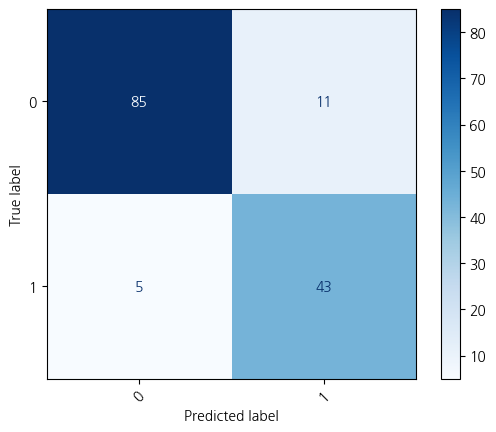

In [20]:


metrics.confusion_matrix(test_target, pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(test_target.unique())
)
disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=45
)

plt.show()